# Q1 - Supervised Learning: Heart Disease Classification

Buiding and Evaluating classification models to predict if patient has heart disease

# Task 1 - Data loading and Inspection

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('q1_heart_disease.csv') #load dataset

print(f"Dataset Shape: {df.shape[0]} rows * {df.shape[1]} columns") #[0] picks the row count and [1] picks the column count

print(f"\nData Types:")
print(df.dtypes) # data types of each column

print(f"\nMissing values per column:")
print(df.isnull().sum())

print(f"\nFirst 5 Rows:")
df.head()



Dataset Shape: 800 rows * 12 columns

Data Types:
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing values per column:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 Rows:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


# Task 2 - Exploratory data analysis

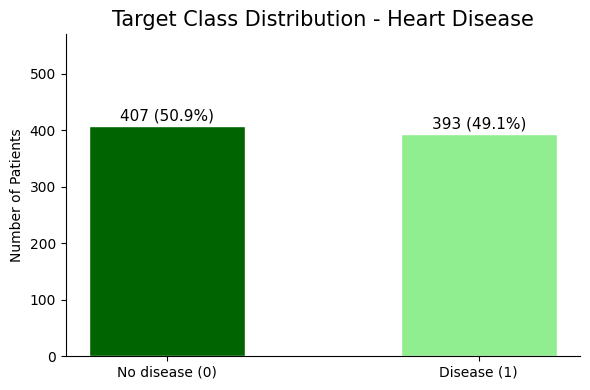

In [4]:
# 1: Target Class Distribution

counts = df['heart_disease'].value_counts() #counts how many times each value (0 and 1) appears ------------ store it in counts

fig, ax = plt.subplots(figsize=(6,4)) #gives the whole figure and chart area
bars = ax.bar(['No disease (0)', 'Disease (1)'], counts.values, # draws a bar chart, labels on the x-axis
              color=['darkgreen', 'lightgreen'], edgecolor = 'white', width=0.5) #gives color and width to bars

for bar, val in zip(bars, counts.values): #pairs each bar with its number value and loops through each bar one at a time 
    ax.text(bar.get_x() + bar.get_width() / 2, #gives the center of the bar
            bar.get_height() + 5, #just above the top of the bar
            f'{val} ({val/len(df)*100:.1f}%)', #count and percentage of total patients and rouind to 1 decimal place
            ha='center', va='bottom', fontsize=11) #horizontal alignment at center and vertical alignment at bottom
    
ax.set_title('Target Class Distribution - Heart Disease', fontsize = 15) #adds title
ax.set_ylabel('Number of Patients') #labels y-axis
ax.set_ylim(0, max(counts.values)*1.4) # sets y-axis range and adds space on top the text above bars
ax.spines[['top', 'right']].set_visible(False) #hides top and right border lines of chart
plt.tight_layout() #avoid overlapping
plt.show() #displays the chart


# Interpretation: 

Dataset is nearly balanced - 407 patients have heart disease (50.9%) and 393 do not (49.1%).
This is ideal as it can prevent the model from being biased towards one class.
Accuracy is reliable metric here, though we still report F1 - score for completeness

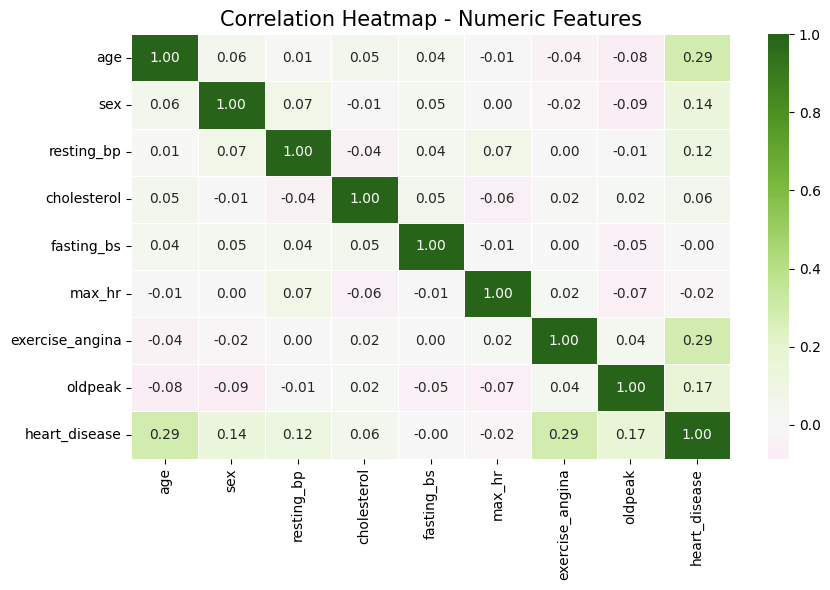

In [5]:
# 2 - Correlation Heatmap
numeric_cols = df.select_dtypes(include=np.number) #picks only numeric column 
corr = numeric_cols.corr() #calculates the correlation between every pair of numeric columns

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt = '.2f', cmap='PiYG', #draws the heatmap ----- show numbers inside each cell ------- format no.s to 2 decimal points ------ colour scheme
            center=0, linewidths=0.7, ax=ax) #whute colour at 0 ----- thin lines between cells ---- draw on the chart area 
ax.set_title('Correlation Heatmap - Numeric Features', fontsize=15)
plt.tight_layout()
plt.show()


# Interpretation:

1) exercise_angina and age are the strongest predictors of heart disease (both +0.29) — patients who get chest pain during exercise and older patients are more likely to have heart disease
2) oldpeak has a moderate positive correlation (+0.17) — higher ST depression after exercise is linked to disease
3) max_hr and cholesterol have almost no correlation with heart disease (-0.02 and +0.06) — which is surprising but that is what this specific dataset shows
4) All correlations are relatively weak (none above 0.30), meaning no single feature alone can predict heart disease — the model needs all features combined to make accurate predictions

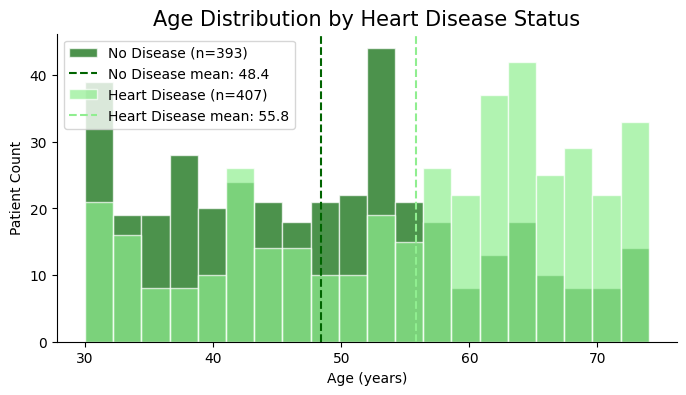

In [6]:
# Age Distribution by Heart Disease Status
fig, ax = plt.subplots(figsize=(8, 4)) 

for label, color, name in [(0, 'darkgreen', 'No Disease'), (1, 'lightgreen', 'Heart Disease')]: #loops twice
    subset = df[df['heart_disease'] == label]['age'] #ages of one group of patients
    ax.hist(subset, bins=20, alpha=0.7, color=color, #Draws histogram --- divide range into 20 buckets ---- 70% opacity 
            label=f'{name} (n={len(subset)})', edgecolor='white')
    ax.axvline(subset.mean(), color=color, linestyle='--', linewidth=1.5, #draws certical line on chart ---- calculate average age of group
               label=f'{name} mean: {subset.mean():.1f}') #shows averge age in the legend rounded to 1 deciaml
    
ax.set_title('Age Distribution by Heart Disease Status', fontsize=15)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Patient Count')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout
plt.show()

# Interpretation:

Patients with heart disease tend to be slightly older on average.
However, distribution overlaps - ages alone cannot predict heart disease.
Hence, we need all 11 features combined to build an accurate model.

# Task 3 - Data Preprocessing


In [7]:
# Step 1 - Handle Missing Values

print(f"Missing values BEFORE imputation:")
print(df[['resting_bp', 'cholesterol']].isnull().sum())

# where there is an empty value fill it with the median of that column
df['resting_bp'] = df['resting_bp'].fillna(df['resting_bp'].median()) #chose median over mean as medical data often contains outliers (high cholestrol) and it is not affected by extreme values.
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median()) 

print(f"\nMissing values AFTER imputation:")
print(df[['resting_bp', 'cholesterol']].isnull().sum()) #check for missing values again

Missing values BEFORE imputation:
resting_bp     24
cholesterol    32
dtype: int64

Missing values AFTER imputation:
resting_bp     0
cholesterol    0
dtype: int64


In [8]:
# Step 2 - One Hot EncodingWarning

category_columns = ['chest_pain_type', 'resting_ecg', 'st_slope'] # these are text columns as ML can only read numbers, so these need to be converted
df_encoded = pd.get_dummies(df, columns=category_columns, drop_first=True) #coverting text to 0/1 columns ---------- dropping first category column of each feature to avoid multicollinearity

print(f"Shape before encoding: {df.shape}")
print(f"Shape after encoding: {df_encoded.shape}")
print(f'\nColumns after encoding: \n{df_encoded.columns.tolist()}') #gives all column names and convert them in python list

Shape before encoding: (800, 12)
Shape after encoding: (800, 16)

Columns after encoding: 
['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak', 'heart_disease', 'chest_pain_type_atypical_angina', 'chest_pain_type_non_anginal', 'chest_pain_type_typical_angina', 'resting_ecg_normal', 'resting_ecg_st_t_wave_abnormality', 'st_slope_flat', 'st_slope_up']


In [12]:
from sklearn.preprocessing import StandardScaler # tool that scales/normalizes numbers
from sklearn.model_selection import train_test_split #tool that splits data into training and testing portions

# Step 3 - Seperate features and target
X = df_encoded.drop('heart_disease', axis = 1) #remove heart disease category_columns --------- Input
y = df_encoded['heart_disease'] # only the heart disease column ---------- Output / Predict

# Step 4 - Train - Test Split
X_train, X_test, y_train, y_test = train_test_split( # Features for training and testing -------- Target answers for training and testing
    X, y, test_size=0.2, stratify=y, random_state=42
)
# test_size = 0.2 -------- means 20% test set ------ 80% data to learn
# stratify ---------- to keep the ratio same i.e. 49 and 51 --------- it looks at y column to ensure the balance
# random_state ------------- fix the randomness 

print(f"Training set: {X_train.shape[0]} samples") # no. of patients in each set
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nClass balance in train: {y_train.value_counts().to_dict()}") # counts no. of 0s and 1s are in training set -------- to verify startify
print(f"Class balance in test: {y_test.value_counts().to_dict()}")

# Step 5 - Scale Features

Scaler = StandardScaler() # brings all coulmns to the small scale (mean = 0, standart deviation = 1) ------------ so that model might not think that big numbers are more important
X_train_scaled = Scaler.fit_transform(X_train) # learn scaling from train data only ---- to prevent data leakage from test set
X_test_scaled = Scaler.transform(X_test) #apply same scaling learned from train

print(f"\nScaling complete.")

Training set: 640 samples
Test set: 160 samples

Class balance in train: {1: 326, 0: 314}
Class balance in test: {1: 81, 0: 79}

Scaling complete.


# Task 4 - Model Training

Train the models using the clean data

In [14]:
from sklearn.tree import DecisionTreeClassifier # contains tree based models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier # contains models made of multiple models

#storing models in 3 different variables and fixing randomness
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gbc = GradientBoostingClassifier(random_state=42)

# Train models
dt.fit(X_train_scaled, y_train) #show the model data to learn the pattern from the features and correct answers for prediction
rf.fit(X_train_scaled, y_train)
gbc.fit(X_train_scaled, y_train)

print(f"Decision Tree - max depth: {dt.get_depth()}") #how many level deep the decision tree grew
print(f"Random Forest - n_estimators: {rf.n_estimators}") # how many trees random forest built
print(f"Gradient Boosting - n_estimators: {gbc.n_estimators}, learning_rate: {gbc.learning_rate}") # how many boosting rounds it did and how much each tree corrects the previous one
print(f"\nAll three models trained successfully.")

Decision Tree - max depth: 13
Random Forest - n_estimators: 100
Gradient Boosting - n_estimators: 100, learning_rate: 0.1

All three models trained successfully.


# Task 5 - Model Evaluation

Test how well each model learned 

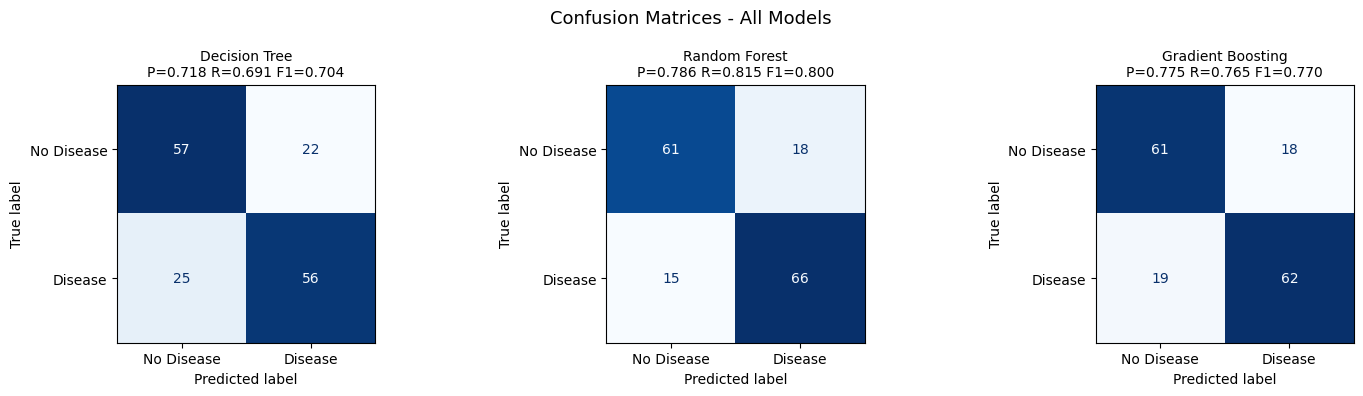

In [17]:
from sklearn.metrics import (confusion_matrix, classification_report, ConfusionMatrixDisplay, precision_score, recall_score, f1_score)

models = {'Decision Tree': dt, 'Random Forest': rf, 'Gradient Boosting': gbc }

results = {}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled) # model looks at the data and predicts 0 or 1 for each

    p = precision_score(y_test, y_pred) #how many patients actually have disease
    r = recall_score(y_test, y_pred) #of those pateients with disease how many model catches ------------ more important
    f1 = f1_score(y_test, y_pred) #no. that balances both precision and recall
    results[name] = {'Precision': p, 'Recall': r, 'F1': f1}

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Disease']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nP={p:.3f} R={r:.3f} F1={f1:.3f}', fontsize=10)

plt.suptitle('Confusion Matrices - All Models', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
#Classification report - visual table of correct/wrong predictions
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

Decision Tree
              precision    recall  f1-score   support

  No Disease       0.70      0.72      0.71        79
     Disease       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160

Random Forest
              precision    recall  f1-score   support

  No Disease       0.80      0.77      0.79        79
     Disease       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

Gradient Boosting
              precision    recall  f1-score   support

  No Disease       0.76      0.77      0.77        79
     Disease       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77     

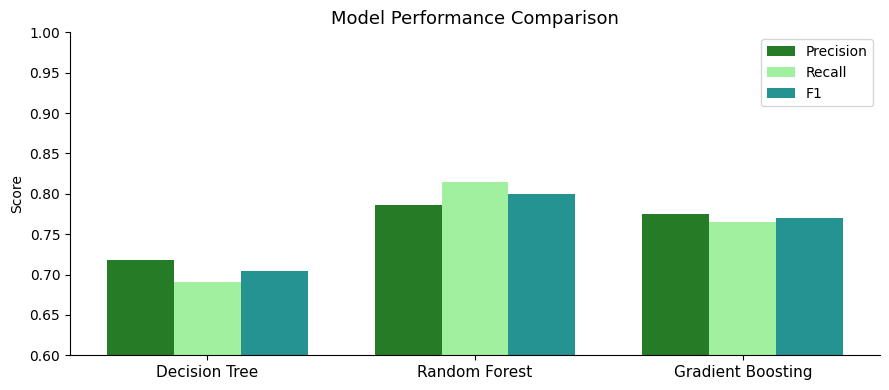


Summary Table:
                   Precision  Recall      F1
Decision Tree         0.7179  0.6914  0.7044
Random Forest         0.7857  0.8148  0.8000
Gradient Boosting     0.7750  0.7654  0.7702


In [23]:
# Summary comparison bar chart
metrics_df = pd.DataFrame(results).T #converts precision, recall, f1 to a table and transpose it

fig, ax = plt.subplots(figsize=(9,4))
x = np.arange(len(metrics_df))
width = 0.25
colors = ['darkgreen', 'lightgreen', 'teal']

for i, (metric, color) in enumerate(zip(['Precision', 'Recall', 'F1'], colors)): #gives us a counter i alongside each item
    ax.bar(x + i * width, metrics_df[metric], width, label=metric, color=color, alpha=0.85) #prevents overlapping

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_df.index, fontsize=11)
ax.set_ylim(0.6, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=13)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\nSummary Table:")
print(metrics_df.round(4).to_string())

# Which model perform best?

Random Forest is the best model because:

1) Achieved highest f1-score - balances precision and recall
2) Best recall for the disease class - catches teh most sick patients among all three models
3) Highest Precision - when it predicts disease, it is correct most often
4) We dont judge by accuracy alone - in medical classificatio,  missing a sick patient is far more costly than a false alarm

# Task 6 - Hyperparameter Tuning

Find the best setting for Random Forest Classifier Model by using GridSearchCV

Check whether the default values(hyperparameters) are best by trying every combination and uses 5-fold cross-validation

In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300], #how many trees forest builds
    'max_depth': [None, 5, 10], #how deep each tree can grow
    'min_samples_split': [2, 5, 10] #minimum no. of patients needed at a node before it can split further
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42), #to train the model internally with different settings
    param_grid, #to read hyperparameters and know which combination to try
    cv=5, # cross validation ------- split training data into 5 equal parts and train/test 5 times
    scoring='f1', #to pick the combination that gives the highest f1 score
    n_jobs=-1, #using all CPU to run that much time faster
    verbose=1 #controls how much infor to print ------ prints basic progress
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best Parameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 300}
Best CV F1-Score: 0.8248


Baseline vs Tuned Random Forest:
             Prediction  Recall  F1-score
Baseline RF      0.7857  0.8148    0.8000
Tuned RF         0.7586  0.8148    0.7857


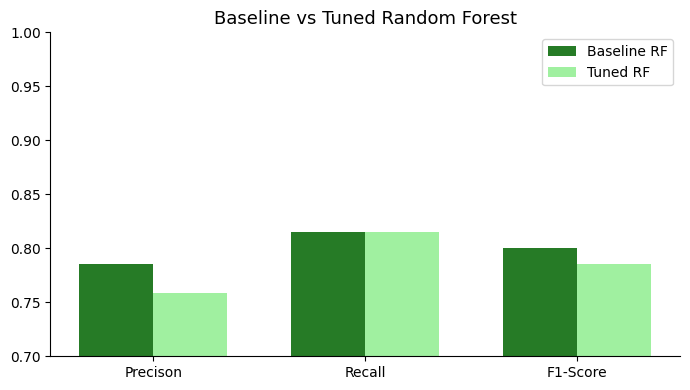

In [28]:
# Compare tuned vs baseline Random forest
best_rf = grid_search.best_estimator_ #model with the best hyperparameters
y_pred_tuned = best_rf.predict(X_test_scaled)
y_pred_base = rf.predict(X_test_scaled)

metrics_compare = {
    'Baseline RF': { 
        'Prediction': precision_score(y_test, y_pred_base),
        'Recall': recall_score(y_test, y_pred_base),
        'F1-score': f1_score(y_test, y_pred_base)
    },
    'Tuned RF':{
        'Prediction': precision_score(y_test, y_pred_tuned),
        'Recall': recall_score(y_test, y_pred_tuned),
        'F1-score': f1_score(y_test, y_pred_tuned)
    }
}

compare_df = pd.DataFrame(metrics_compare).T #converts dictionary into a table
print(f"Baseline vs Tuned Random Forest:")
print(compare_df.round(4).to_string())

# Bar chart comparison
fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(3) #creates array
width = 0.35
ax.bar(x - width/2, compare_df.loc['Baseline RF'], width, label ='Baseline RF', color='darkgreen', alpha=0.85)
ax.bar(x + width/2, compare_df.loc['Tuned RF'], width, label ='Tuned RF', color='lightgreen', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(['Precison', 'Recall', 'F1-Score'])
ax.set_ylim(0.7, 1)
ax.set_title('Baseline vs Tuned Random Forest', fontsize=13)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

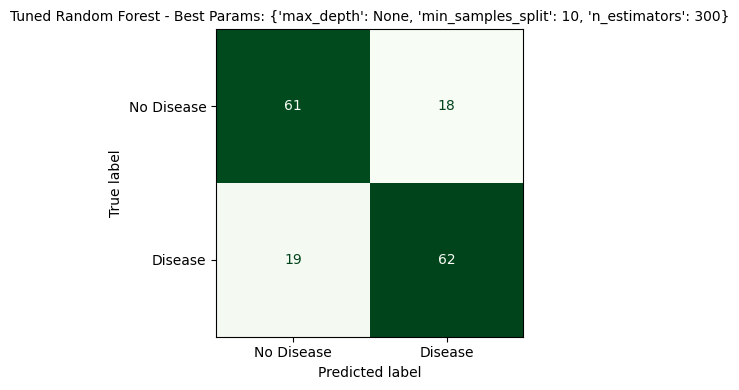


Classification Report - Tuned Random Forest:
              precision    recall  f1-score   support

  No Disease       0.79      0.73      0.76        79
     Disease       0.76      0.81      0.79        81

    accuracy                           0.78       160
   macro avg       0.78      0.77      0.77       160
weighted avg       0.78      0.78      0.77       160



In [29]:
# Confusion matrix for tuned model

fig, ax = plt.subplots(figsize=(5,4))
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Disease']).plot(
    ax=ax, colorbar=False, cmap='Greens')
ax.set_title(f"Tuned Random Forest - Best Params: {grid_search.best_params_}", fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nClassification Report - Tuned Random Forest:")
print(classification_report(y_test, y_pred_tuned, target_names=['No Disease', 'Disease']))

# Conclusion

The tuned Random Forest Classfier is our best model for predicting heart disease, achieving the highest F1-score and recall among all models tested